# установка зависимостей/импорт библиотек

In [ ]:
%pip install numpy
%pip install scikit-learn
%pip install torch torchvision
%pip install optuna
%pip install ipywidgets
%pip install matplotlib
%pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may ne

In [2]:

import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib
import matplotlib.pyplot as plt

# настройка torch

In [3]:
# я сижу на маке поэтому выбираю mps, вы можете выбрать cuda или cpu
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

torch.set_float32_matmul_precision("high")

Device: mps


# предобработка данных

In [4]:
# загружаю данные
df = pd.read_csv("Symbols_1m_1ch_PR_1.csv", header=None)

tx_symbols = torch.tensor(df.iloc[:, 0:2].values, dtype=torch.float32)
rx_symbols = torch.tensor(df.iloc[:, 2:4].values, dtype=torch.float32)

# созвездие 16-QAM нормализованное + битовые метки
constellation = torch.tensor([
    [-0.948683, -0.948683],
    [-0.948683, -0.316228],
    [-0.948683,  0.316228],
    [-0.948683,  0.948683],
    [-0.316228, -0.948683],
    [-0.316228, -0.316228],
    [-0.316228,  0.316228],
    [-0.316228,  0.948683],
    [ 0.316228, -0.948683],
    [ 0.316228, -0.316228],
    [ 0.316228,  0.316228],
    [ 0.316228,  0.948683],
    [ 0.948683, -0.948683],
    [ 0.948683, -0.316228],
    [ 0.948683,  0.316228],
    [ 0.948683,  0.948683],
], device=device)

# битовые метки для каждой точки созвездия
bit_labels = torch.tensor([
    [0,0,0,0],[0,0,0,1],[0,0,1,1],[0,0,1,0],
    [0,1,0,0],[0,1,0,1],[0,1,1,1],[0,1,1,0],
    [1,1,0,0],[1,1,0,1],[1,1,1,1],[1,1,1,0],
    [1,0,0,0],[1,0,0,1],[1,0,1,1],[1,0,1,0]
], device=device)

# демодуляция и расчет BER
def symbols_to_classes(symbols: torch.Tensor) -> torch.Tensor:
    diff = symbols.unsqueeze(1) - constellation.unsqueeze(0)
    dist = torch.sum(diff ** 2, dim=2)
    return torch.argmin(dist, dim=1)

def ber_from_classes(tx_cls: torch.Tensor, rx_cls: torch.Tensor) -> float:
    tx_bits = bit_labels[tx_cls]
    rx_bits = bit_labels[rx_cls]
    return (tx_bits != rx_bits).float().mean().item()

ber = ber_from_classes(
    symbols_to_classes(tx_symbols.to(device)),
    symbols_to_classes(rx_symbols.to(device))
)
print(f"Bit Error Rate (BER): {ber}")

Bit Error Rate (BER): 0.0081024169921875


# подготовка датасета

In [ ]:
# подготовка оконного датасета (ОКНО = 5)
class WindowedSymbolDataset(Dataset):
    def __init__(self, rx_symbols: torch.Tensor, tx_classes: torch.Tensor,
                 k: int = 30, normalize: bool = True, noise_std: float = 0.0):
        self.k = k if k is not None else CFG.context_k
        self.noise_std = noise_std
        self.X, self.y = self._create_windows(rx_symbols, tx_classes)

        if normalize:
            self.mean = self.X.mean(dim=0, keepdim=True)
            self.std = self.X.std(dim=0, keepdim=True)
            self.std[self.std == 0] = 1.0
            self.X = (self.X - self.mean) / self.std
        else:
            self.mean = None
            self.std = None

        self.training = False

    def _create_windows(self, rx_symbols: torch.Tensor, tx_classes: torch.Tensor):
        X, y = [], []
        for i in range(self.k, len(rx_symbols) - self.k):
            window = rx_symbols[i - self.k:i + self.k + 1].reshape(-1)
            X.append(window)
            y.append(tx_classes[i])
        return torch.stack(X), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.noise_std > 0 and self.training:
            x = x + torch.randn_like(x) * self.noise_std
        return x, y

    def set_training(self, is_training: bool):
        self.training = is_training




tx_classes = symbols_to_classes(tx_symbols.to(device)).cpu()

def make_windows(rx: torch.Tensor, tx_cls: torch.Tensor, k=2):
    X, y = [], []
    for i in range(k, len(rx) - k):
        X.append(rx[i-k:i+k+1].reshape(-1))
        y.append(tx_cls[i])
    return torch.stack(X), torch.tensor(y)

X, y = make_windows(rx_symbols, tx_classes, k=2)

split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

X_train = X[:split_idx]
y_train = y[:split_idx]

X_val = X[split_idx:]
y_val = y[split_idx:]

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)


# модель

In [ ]:
# создаю модель WNN
class RxWindowNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(10, hidden),
        nn.Tanh(),
        nn.Dropout(0.1),
        nn.Linear(hidden, hidden),
        nn.Tanh(),
        nn.Dropout(0.1),
        nn.Linear(hidden, 16)
)

    def forward(self, x):
        return self.net(x)

model = RxWindowNet(hidden=256).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)  # L2 регуляризация
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
criterion = nn.CrossEntropyLoss()

# функция для ранней остановки
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop
    
class TrainingLoop:
    def __init__(self, model, optimizer, criterion, train_loader, val_loader, scheduler, device):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.scheduler = scheduler
        self.device = device
    def train(self, num_epochs=1000):
        train_losses = []
        val_losses = []
        val_accuracies = []
        early_stopping = EarlyStopping(patience=20)

        best_val_loss = float('inf')
        best_model_state = None

        for epoch in range(num_epochs):
            self.model.train()
            running_loss = 0.0
            for inputs, labels in self.train_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            avg_train_loss = running_loss / len(self.train_loader.dataset)
            train_losses.append(avg_train_loss)

            # валидация
            self.model.eval()
            val_running_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, labels in self.val_loader:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels)
                    val_running_loss += loss.item() * inputs.size(0)

                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            avg_val_loss = val_running_loss / len(self.val_loader.dataset)
            val_losses.append(avg_val_loss)
            val_accuracy = correct / total
            val_accuracies.append(val_accuracy)

            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scheduler.step(avg_val_loss)

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = self.model.state_dict().copy()  
                print(f"Эпоха {epoch+1:03d}: лучшая модель сохранена; Val Loss: {avg_val_loss:.6f}")

            # проверка на раннюю остановку
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = self.model.state_dict()

            if early_stopping(avg_val_loss):
                print(f"Ранняя остановка на эпохе {epoch+1}")
                break

            if (epoch + 1) % 10 == 0:
                print(f"Эпоха {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

        # загружаем лучшие веса модели
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        return train_losses, val_losses, val_accuracies
    def evaluate_model(self, model, test_loader, device):
        model.eval()
        total_correct = 0
        total_samples = 0
        total_loss = 0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for rx_win, cls in test_loader:
                rx_win = rx_win.to(device)
                cls = cls.to(device)

                logits = model(rx_win)
                loss = criterion(logits, cls)

                preds = logits.argmax(dim=1)
                total_correct += (preds == cls).sum().item()
                total_samples += cls.size(0)
                total_loss += loss.item()

        accuracy = total_correct / total_samples
        avg_loss = total_loss / len(test_loader)

        return avg_loss, accuracy


# обучение модели

In [7]:

epochs = 1000
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
patience_limit = 40
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    # тренировка
    model.train()
    total_train_loss = 0.0
    train_batches = 0
    
    for rx_win, cls in train_loader:
        rx_win = rx_win.to(device)
        cls = cls.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast("mps", torch.float16):
            logits = model(rx_win)
            loss = criterion(logits, cls)

        loss.backward()
        # градиент клиппинг для стабильности
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += loss.item()
        train_batches += 1

    avg_train_loss = total_train_loss / train_batches

    # валидол
    model.eval()
    total_val_loss = 0.0
    val_batches = 0
    correct_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for rx_win, cls in val_loader:
            rx_win = rx_win.to(device)
            cls = cls.to(device)

            with torch.autocast("mps", torch.float16):
                logits = model(rx_win)
                loss = criterion(logits, cls)

            total_val_loss += loss.item()
            val_batches += 1

            preds = logits.argmax(dim=1)
            correct_predictions += (preds == cls).sum().item()
            total_val_samples += cls.size(0)
    
    avg_val_loss = total_val_loss / val_batches
    val_accuracy = correct_predictions / total_val_samples

    # сохранение лучшей модели
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()  
        patience_counter = 0  
        print(f"Эпоха {epoch+1:03d}: лучшая модель сохранена; Val Loss: {avg_val_loss:.6f}")
    else:
        patience_counter += 1

    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    if patience_counter >= patience_limit:
        print(f"Ранняя остановка на эпохе: {epoch+1}")
        print(f"Лучшая val loss: {best_val_loss:.6f}")
        break
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

# загрузка лучшей модели
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Загружена модель с лучшей val loss: {best_val_loss:.6f}")

Эпоха 001: лучшая модель сохранена; Val Loss: 0.233461
Эпоха 002: лучшая модель сохранена; Val Loss: 0.154145
Эпоха 003: лучшая модель сохранена; Val Loss: 0.149021
Эпоха 004: лучшая модель сохранена; Val Loss: 0.127619
Эпоха 010 | Train Loss: 0.1112 | Val Loss: 0.1373 | Val Acc: 0.9512 | LR: 1.00e-03
Эпоха 016: лучшая модель сохранена; Val Loss: 0.120755
Эпоха 018: лучшая модель сохранена; Val Loss: 0.119458
Эпоха 020 | Train Loss: 0.0862 | Val Loss: 0.1279 | Val Acc: 0.9579 | LR: 5.00e-04
Эпоха 030 | Train Loss: 0.0716 | Val Loss: 0.1200 | Val Acc: 0.9603 | LR: 2.50e-04
Эпоха 032: лучшая модель сохранена; Val Loss: 0.118668
Эпоха 040 | Train Loss: 0.0685 | Val Loss: 0.1225 | Val Acc: 0.9585 | LR: 2.50e-04
Эпоха 045: лучшая модель сохранена; Val Loss: 0.117747
Эпоха 050 | Train Loss: 0.0664 | Val Loss: 0.1193 | Val Acc: 0.9591 | LR: 1.25e-04
Эпоха 060 | Train Loss: 0.0593 | Val Loss: 0.1191 | Val Acc: 0.9594 | LR: 6.25e-05
Эпоха 070 | Train Loss: 0.0593 | Val Loss: 0.1195 | Val Acc: 0

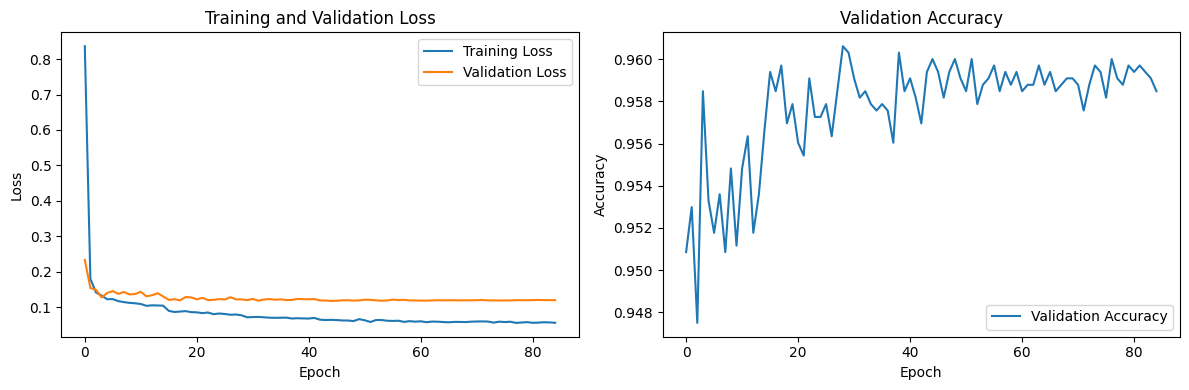

In [ ]:
# Визуализация обучения

def plot_training_curves(train_losses, val_losses, val_accuracies):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Validation Accuracy')

    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

plot_training_curves(train_losses, val_losses, val_accuracies)


In [9]:
# оценка модели на обученной на одном файле
model.eval()
with torch.no_grad(), torch.autocast("mps", torch.float16):
    pred_cls = model(X.to(device)).argmax(dim=1)

ber_before = ber_from_classes(
    tx_classes[2:-2],
    symbols_to_classes(rx_symbols.to(device))[2:-2]
)

ber_after = ber_from_classes(
    tx_classes[2:-2],
    pred_cls
)

print("\nИтог")
print(f"BER до модели:    {ber_before:.6f}")
print(f"BER после модели: {ber_after:.6f}")


Итог
BER до модели:    0.008089
BER после модели: 0.004823


In [ ]:
# теперь мы будем загружать первые 8
tx_list = []
rx_list = []


for file_idx in range(2, 9):
    df = pd.read_csv(f"Symbols_1m_1ch_PR/Symbols_1m_1ch_PR_{file_idx}.csv", header=None)

    tx_list.append(torch.tensor(df.iloc[:, 0:2].values, dtype=torch.float32))
    rx_list.append(torch.tensor(df.iloc[:, 2:4].values, dtype=torch.float32))
  
tx_all = torch.cat(tx_list, dim=0)
rx_all = torch.cat(rx_list, dim=0)

tx_classes = symbols_to_classes(tx_all.to(device)).cpu()
X_new, y_new = make_windows(rx_all, tx_classes, k=2)

dataset_new = TensorDataset(X_new, y_new)
train_size = int(0.8 * len(dataset_new))
val_size = len(dataset_new) - train_size
train_dataset_new, val_dataset_new = random_split(dataset_new, [train_size, val_size])

train_loader_new = DataLoader(train_dataset_new, batch_size=32, shuffle=True)
val_loader_new = DataLoader(val_dataset_new, batch_size=32, shuffle=False)

training_loop = TrainingLoop(model, optimizer, criterion, train_loader_new, val_loader_new, scheduler, device)
train_losses, val_losses, val_accuracies = training_loop.train(num_epochs=100)

plot_training_curves(train_losses, val_losses, val_accuracies)

Эпоха 10 | Loss: 0.1047 | Val Loss: 0.0959 | Val Acc: 0.9662
Эпоха 20 | Loss: 0.1045 | Val Loss: 0.0956 | Val Acc: 0.9663
Ранняя остановка на эпохе 21


([0.10621224657750782,
  0.10715662494388344,
  0.1058103471639684,
  0.10688629736253603,
  0.10671131899014341,
  0.10583508478051194,
  0.10567839757466864,
  0.1059663859845112,
  0.10509552480947815,
  0.10467749477103253,
  0.1040525372010715,
  0.10549757132169636,
  0.1048960815794522,
  0.10432530105301899,
  0.1032473686545415,
  0.10523348471673806,
  0.10446420998532413,
  0.10465197617314313,
  0.10502285411232021,
  0.10453102979969228,
  0.10426450713586063],
 [0.09418916388291732,
  0.09450535166873997,
  0.09460569287859355,
  0.09465314746169375,
  0.0949539616424635,
  0.09490907928485445,
  0.09528344394974926,
  0.09506547087406787,
  0.09544600944371805,
  0.0958512012332362,
  0.09535239219818846,
  0.09558186747415358,
  0.09564405537103252,
  0.09548837773694496,
  0.09559570309707778,
  0.09555452950316652,
  0.09553429434571233,
  0.0956494944040105,
  0.09567926656351669,
  0.09561295756201188,
  0.09567853973025862],
 [0.9668221650608188,
  0.96656057897719

In [13]:
# считаем BER на всех файлах после дообучения
all_tx_symbols = []
all_rx_symbols = []
for file_idx in range(9, 11):
    df = pd.read_csv(f"Symbols_1m_1ch_PR/Symbols_1m_1ch_PR_{file_idx}.csv", header=None)

    tx_symbols = torch.tensor(df.iloc[:, 0:2].values, dtype=torch.float32)
    rx_symbols = torch.tensor(df.iloc[:, 2:4].values, dtype=torch.float32)

    all_tx_symbols.append(tx_symbols)
    all_rx_symbols.append(rx_symbols)
all_tx_symbols = torch.cat(all_tx_symbols, dim=0)
all_rx_symbols = torch.cat(all_rx_symbols, dim=0)


tx_classes_all = symbols_to_classes(all_tx_symbols.to(device)).cpu()
X, y = make_windows(all_rx_symbols, tx_classes_all, k=2)

model.eval()
with torch.no_grad(), torch.autocast("mps", torch.float16):
    pred_cls = model(X.to(device)).argmax(dim=1)    

ber = ber_from_classes(
    symbols_to_classes(all_tx_symbols.to(device)),
    symbols_to_classes(all_rx_symbols.to(device))
)
print(f"\nОбщий BER: {ber}")

ber_after_training = ber_from_classes(
    symbols_to_classes(all_tx_symbols.to(device))[2:-2],
    pred_cls
)
print(f"\nОбщий BER после дообучения на всех файлах: {ber_after_training}") 


Общий BER: 0.01023101806640625

Общий BER после дообучения на всех файлах: 0.009331888519227505
